In [35]:
!pip install scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 5.4 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.0/318.0 kB 4.5 MB/s eta 0:00:00m eta 0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 6.1 MB/s eta 0:00:00 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.8/273.8 kB 5.7 MB/s eta 0:00:007.2 MB/s eta 0:00:01


In [36]:
import numpy as np
from aicspylibczi import CziFile
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter 
from skimage.filters import threshold_otsu

In [7]:
pth = Path('img/SEcell7.czi')
czi = CziFile(pth)

In [8]:
img_frames = []
for t in range(0,250):
    frame_t, _ = czi.read_image(Z=0, T=t, C=0, H=0)
    img_frames.append(frame_t[0, 0, 0, 0, :, :])

img_frames = np.array(img_frames)
img_frames.shape

(250, 512, 512)

In [59]:
frame_idx = 131
frame = np.copy(img_frames[frame_idx])

frame = gaussian_filter(frame, sigma=1.5)

threshold = threshold_otsu(frame)

# Apply the threshold mask
otsu_frame = frame > threshold

In [ ]:
TILE_SIZE = 64
stride_proportion = 1/2
stride = int(TILE_SIZE * stride_proportion)

In [86]:
tiles = [
    frame[x:x + TILE_SIZE, y:y + TILE_SIZE]
    for x in range(0, frame.shape[0] - TILE_SIZE + 1, stride)
    for y in range(0, frame.shape[1] - TILE_SIZE + 1, stride)
]

tile_amount = len(tiles)

otsu_tiles = [threshold_otsu(tile) for tile in tiles]

otsu_result_tiles = [
    tile > otsu_threshold
    for tile, otsu_threshold in zip(tiles, otsu_tiles)
]

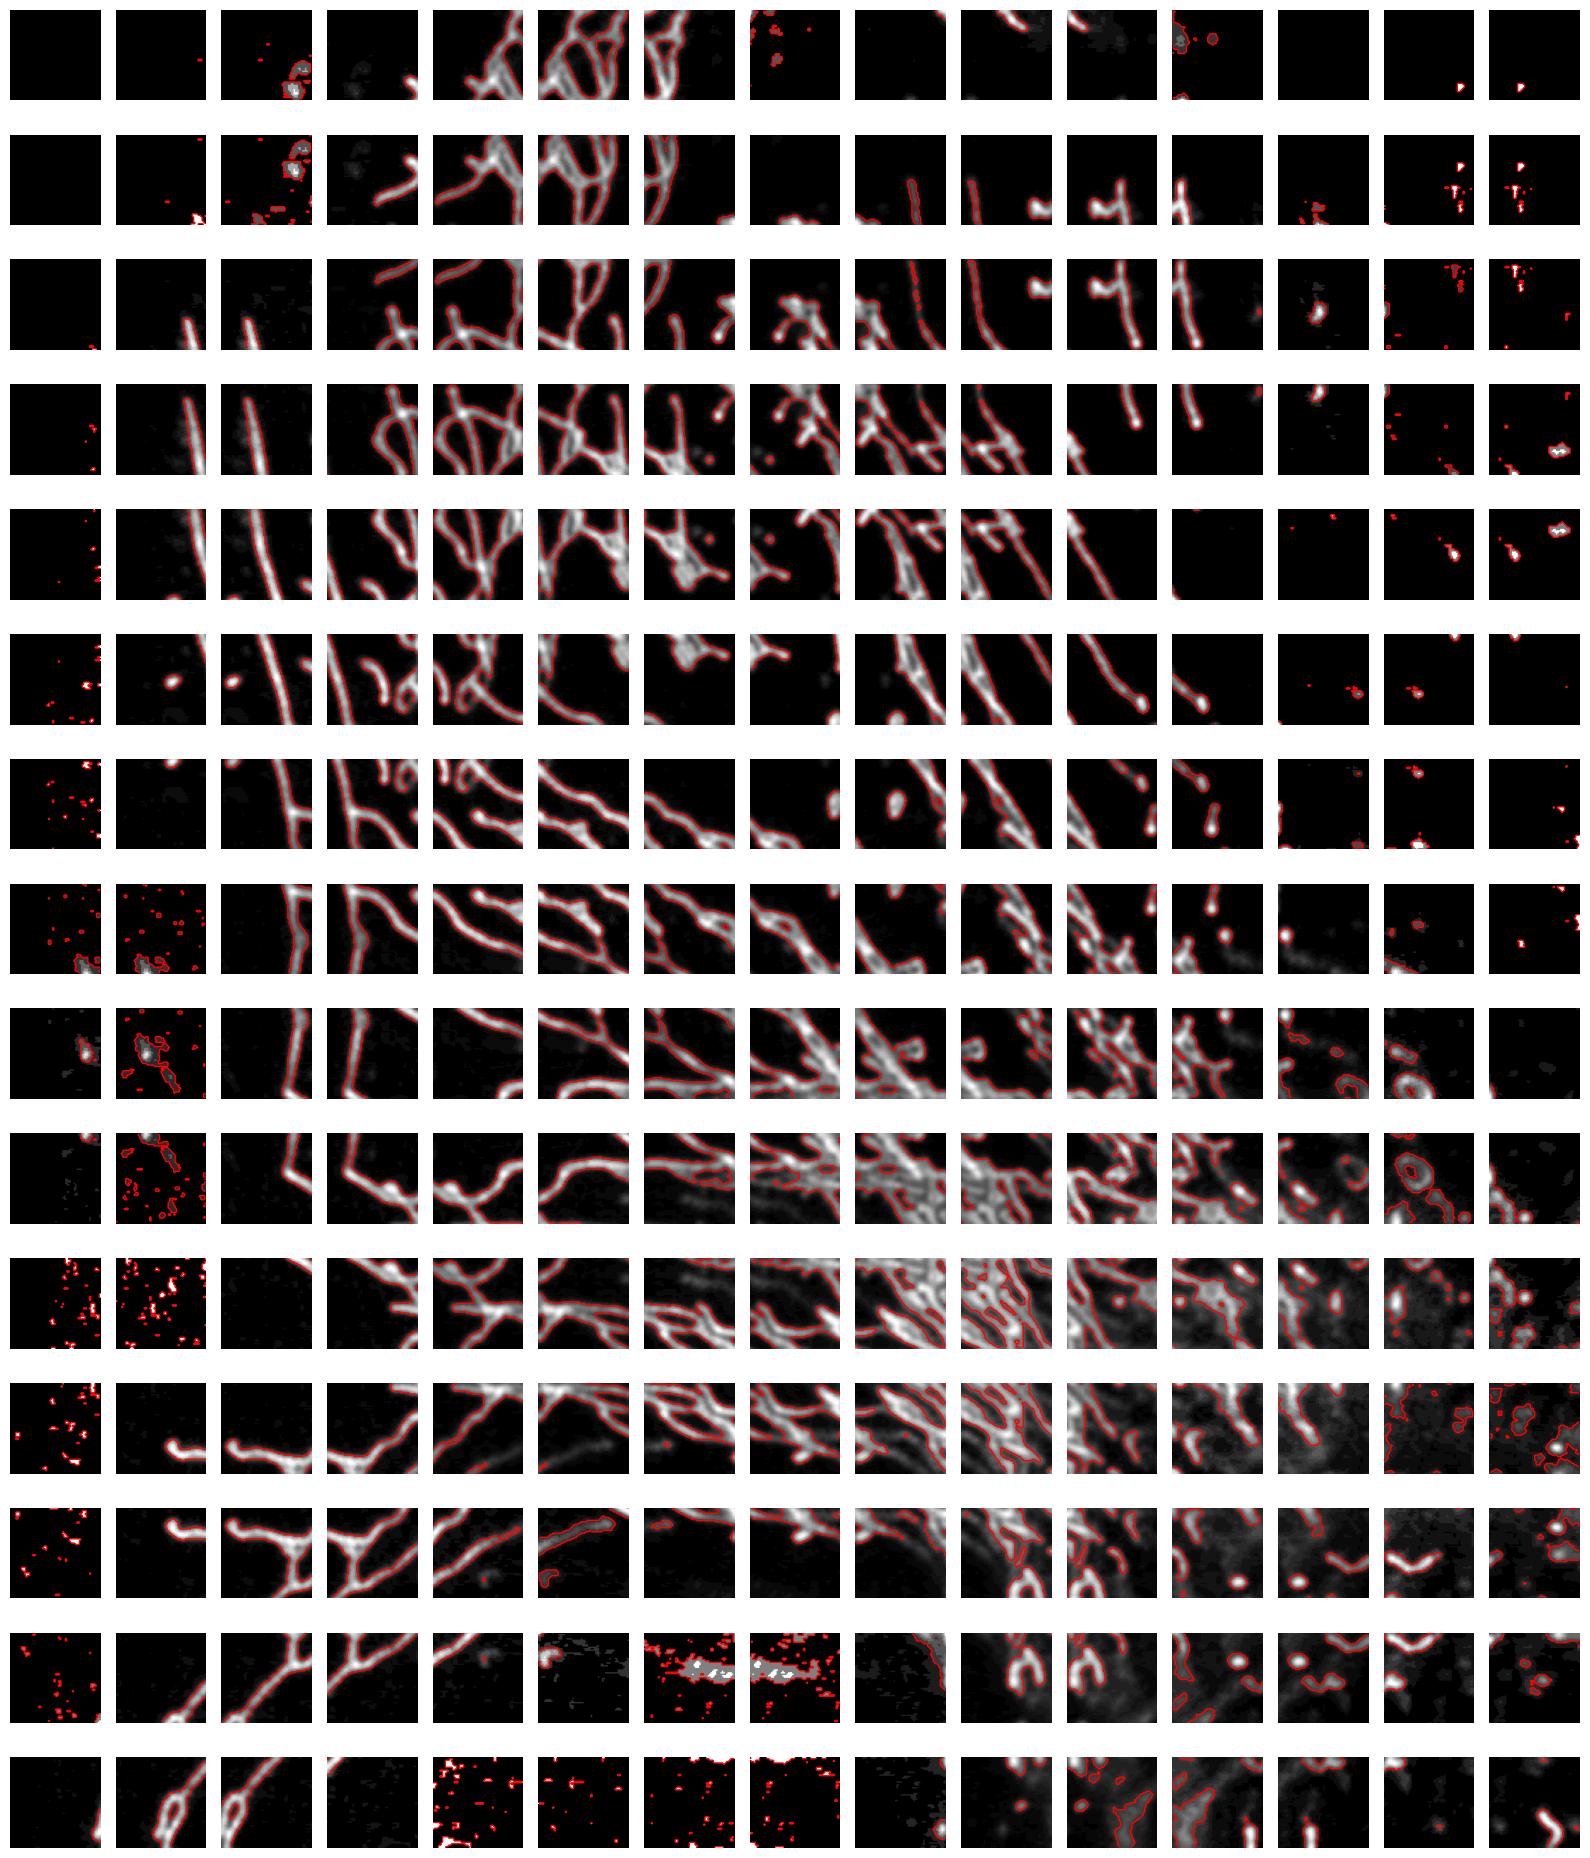

In [87]:
x_positions = range(0, frame.shape[0] - TILE_SIZE + 1, stride)
y_positions = range(0, frame.shape[1] - TILE_SIZE + 1, stride)

nrows = len(x_positions)
ncols = len(y_positions)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 19),
    squeeze=False
)

for idx, (tile, mask) in enumerate(zip(tiles, otsu_result_tiles)):
    row = idx // ncols
    col = idx % ncols

    axes[row, col].imshow(tile, cmap="gray")
    axes[row, col].contour(
        mask,
        levels=[0.5],
        colors="red",
        linewidths=1
    )
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()